# **1. Clean Training Data**

### **Import Data**

In [1]:
import pandas as pd
import numpy as np
df_tran_raw = pd.read_csv(r'U:\Zeming\AAA-Project\DME Fraud Claims Detection\Training Data\raw_training_data.csv')
df_tran = df_tran_raw.copy()

#Suspious Claims Flag As Non Fraud
df_tran['fraud_flag'] = df_tran['fraud_flag'].replace({'Suspious':0,'Confirmed':1}).fillna(0).astype(int)

C:\Users\zliu\AppData\Local\Temp\ipykernel_30052\3235739328.py:3: DtypeWarning: Columns (9,10,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tran_raw = pd.read_csv(r'U:\Zeming\AAA-Project\DME Fraud Claims Detection\Training Data\raw_training_data.csv')


### **Check Column Data Types**

In [7]:
#check data type
print(df_tran.dtypes.to_string())

cur_clm_uniq_id                                      int64
clm_chrg_amt                                       float64
clm_paid_amt                                       float64
clm_lines_ct                                         int64
clm_all_cpts                                        object
clm_uniq_cpt_ct                                      int64
clm_from_dt                                         object
clm_thru_dt                                 datetime64[ns]
clm_beneficiary_id                                  object
clm_billnpi                                         object
clm_ordnpi                                          object
clm_from_month                                       int64
clm_from_day                                         int64
clm_duration_days                                    int64
original_clm_flag                                    int64
fraud_flag                                           int64
risk_cpt_flag                                        int

### **Fill NA Values**

In [ ]:
#df_tran.isna().sum().sort_values(ascending=False).to_dict()

In [9]:
#for claim that bene doesn't have claim in past 2 years, fill with 999
df_tran['bene_days_last_claim'] = df_tran['bene_days_last_claim'].fillna(999)

cols = ['billnpi_top1_cpt_chrg_amt_percentage_365days',
        'billnpi_top5_cpt_chrg_amt_percentage_365days',
        'billnpi_top1_cpt_paid_amt_percentage_365days',
        'billnpi_top5_cpt_paid_amt_percentage_365days',
        'billnpibene_%paid_on_this_patient_365days',
        'billnpibene_%chrg_on_this_patient_365days',
        'ordenpi_top1_cpt_chrg_amt_percentage_365days',
        'ordenpi_top5_cpt_chrg_amt_percentage_365days',
        'ordenpi_top1_cpt_paid_amt_percentage_365days',
        'ordenpi_top5_cpt_paid_amt_percentage_365days',
        'ordenpibene_%paid_on_this_patient_365days',
        'ordenpibene_%chrg_on_this_patient_365days']
df_tran[cols] = df_tran[cols].fillna(0)

#show na after filling
df_tran.isna().sum().sort_values(ascending=False).head(10).to_dict()

{'cur_clm_uniq_id': 0,
 'npi_top1_cpt_chrg_amt_365days': 0,
 'npi_avg_paid_amt_per_claim_30days': 0,
 'npi_avg_chrg_amt_per_claim_365days': 0,
 'npi_avg_chrg_amt_per_claim_90days': 0,
 'npi_avg_chrg_amt_per_claim_30days': 0,
 'npi_avg_paid_amt_per_patient_365days': 0,
 'npi_avg_paid_amt_per_patient_90days': 0,
 'npi_avg_paid_amt_per_patient_30days': 0,
 'npi_avg_chrg_amt_per_patient_365days': 0}

### **Process Infinite Values**

In [10]:
# 检查每列 inf 数量
num_cols = df_tran.select_dtypes(include=np.number).columns
inf_counts = pd.Series(np.isinf(df_tran[num_cols]).sum(axis=0), index=num_cols)
print("每列无穷大值数量：")
print(inf_counts[inf_counts > 0])  # 只显示有 inf 的列

每列无穷大值数量：
npi_top1_cpt_chrg_amt_percentage_365days    6237
npi_top5_cpt_chrg_amt_percentage_365days    6237
npi_top1_cpt_paid_amt_percentage_365days    6882
npi_top5_cpt_paid_amt_percentage_365days    6882
dtype: int64


In [11]:
#Replace Infinity Values
num_cols = df_tran.select_dtypes(include=np.number).columns
df_tran[num_cols] = df_tran[num_cols].replace([np.inf, -np.inf], 0)

#check if any columns still with infinite values
print((np.isinf(df_tran[num_cols])).values.any())

False


### **Check Data Distribution**

In [12]:
#check data shape
df_tran.shape

(1767488, 125)

In [13]:
#check fraud distribution
print(df_tran['fraud_flag'].value_counts())
print(df_tran['fraud_flag'].value_counts(normalize=True))

fraud_flag
0    1764965
1       2523
Name: count, dtype: int64
fraud_flag
0    0.998573
1    0.001427
Name: proportion, dtype: float64


In [14]:
#check every column numeric distribution
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.float_format', lambda x: f'{x:.3f}')  # 保留3位小数，可改成 t
df_tran.describe()

,cur_clm_uniq_id,clm_chrg_amt,clm_paid_amt,clm_lines_ct,clm_uniq_cpt_ct,clm_thru_dt,clm_from_month,clm_from_day,clm_duration_days,original_clm_flag,fraud_flag,risk_cpt_flag,bene_clmline_ct_30days,bene_clmline_ct_90days,bene_clmline_ct_365days,bene_clmheader_ct_30days,bene_clmheader_ct_90days,bene_clmheader_ct_365days,bene_uniq_cpt_ct_30days,bene_uniq_cpt_ct_90days,bene_uniq_cpt_ct_365days,bene_chrg_amt_30days,bene_chrg_amt_90days,bene_chrg_amt_365days,bene_paid_amt_30days,bene_paid_amt_90days,bene_paid_amt_365days,bene_risk_cpt_ct_30days,bene_risk_cpt_ct_90days,bene_risk_cpt_ct_365days,bene_uniq_ordernpi_30days,bene_uniq_ordNpi_90days,bene_uniq_ordnpi_365days,bene_uniq_billnpi_30days,bene_uniq_billnpi_90days,bene_uniq_billnpi_365days,bene_days_last_claim,bene_seen_billnpi_ct_30days,bene_seen_billnpi_ct_90days,bene_seen_billnpi_ct_365days,bene_seen_ordnpi_ct_30days,bene_seen_orfnpi_ct_90days,bene_seen_ordnpi_ct_365days,bene_seen_ordnpi_5years,bene_avg_chrg_amt_per_claim_30days,bene_avg_chrg_amt_per_claim_90days,bene_avg_chrg_amt_per_claim_365days,bene_avg_paid_amt_per_claim_30days,bene_avg_paid_amt_per_claim_90days,bene_avg_paid_amt_per_claim_365days,bene_bill_Orde_%_30days,npi_clmline_ct_30days,npi_clmline_ct_90days,npi_clmline_ct_365days,npi_clmheader_ct_30days,npi_clmheader_ct_90days,npi_clmheader_ct_365days,npi_uniq_bene_ct_30days,npi_uniq_bene_ct_90days,npi_uniq_bene_ct_365days,npi_chrg_amt_30days,npi_chrg_amt_90days,npi_chrg_amt_365days,npi_paid_amt_30days,npi_paid_amt_90days,npi_paid_amt_365days,npi_risk_cpt_ct_30days,npi_risk_cpt_ct_90days,npi_risk_cpt_ct_365days,npi_new_bene_ct_30days,npi_new_bene_ct_90days,npi_new_bene_ct_365days,npi_top1_cpt_clmline_ct_365days,npi_top5_cpt_clmline_ct_365days,npi_top1_cpt_chrg_amt_365days,npi_top5_cpt_chrg_amt_365days,npi_top1_cpt_paid_amt_365days,npi_top5_cpt_paid_amt_365days,npi_avg_chrg_amt_per_patient_30days,npi_avg_chrg_amt_per_patient_90days,npi_avg_chrg_amt_per_patient_365days,npi_avg_paid_amt_per_patient_30days,npi_avg_paid_amt_per_patient_90days,npi_avg_paid_amt_per_patient_365days,npi_avg_chrg_amt_per_claim_30days,npi_avg_chrg_amt_per_claim_90days,npi_avg_chrg_amt_per_claim_365days,npi_avg_paid_amt_per_claim_30days,npi_avg_paid_amt_per_claim_90days,npi_avg_paid_amt_per_claim_365days,npi_risk_cpt_percentage_30days,npi_risk_cpt_percentage_90days,npi_risk_cpt_percentage_365days,npi_top1_cpt_percentage_365days,npi_top5_cpt_percentage_365days,npi_top1_cpt_chrg_amt_percentage_365days,npi_top5_cpt_chrg_amt_percentage_365days,npi_top1_cpt_paid_amt_percentage_365days,npi_top5_cpt_paid_amt_percentage_365days,npi_new_patients_percentage_365days,npi_30days_claim_percentage_to_365days,npi_90days_claim_percentage_to_365days,npibene_clmline_ct_30days,npibene_clmline_ct_90days,npibene_clmline_ct_365days,npibene_clmheader_ct_30days,npibene_clmheader_ct_90days,npibene_clmheader_ct_365days,npibene_uniq_cpt_ct_30days,npibene_uniq_cpt_ct_90days,npibene_uniq_cpt_ct_365days,npibene_chrg_amt_30days,npibene_chrg_amt_90days,npibene_chrg_amt_365days,npibene_paid_amt_30days,npibene_paid_amt_90days,npibene_paid_amt_365days,npibene_%claim_on_this_patient_365days,npibene_%paid_on_this_patient_365days,npibene_%chrg_on_this_patient_365days
count,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,1767488.000,

In [15]:
#check distribution by fraud flag
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.float_format', lambda x: f'{x:.3f}')  # 保留3位小数，可改成 t

# 选择整数型列
int_cols = df_tran.select_dtypes(include=['int64','float64']).columns
# 对整数列按 fraud_flag 分组计算中位数
#df_tran.groupby('fraud_flag')[int_cols].median()
df_tran.groupby('fraud_flag')[int_cols].mean()

,cur_clm_uniq_id,clm_chrg_amt,clm_paid_amt,clm_lines_ct,clm_uniq_cpt_ct,clm_from_month,clm_from_day,clm_duration_days,original_clm_flag,fraud_flag,risk_cpt_flag,bene_clmline_ct_30days,bene_clmline_ct_90days,bene_clmline_ct_365days,bene_clmheader_ct_30days,bene_clmheader_ct_90days,bene_clmheader_ct_365days,bene_uniq_cpt_ct_30days,bene_uniq_cpt_ct_90days,bene_uniq_cpt_ct_365days,bene_chrg_amt_30days,bene_chrg_amt_90days,bene_chrg_amt_365days,bene_paid_amt_30days,bene_paid_amt_90days,bene_paid_amt_365days,bene_risk_cpt_ct_30days,bene_risk_cpt_ct_90days,bene_risk_cpt_ct_365days,bene_uniq_ordernpi_30days,bene_uniq_ordNpi_90days,bene_uniq_ordnpi_365days,bene_uniq_billnpi_30days,bene_uniq_billnpi_90days,bene_uniq_billnpi_365days,bene_days_last_claim,bene_seen_billnpi_ct_30days,bene_seen_billnpi_ct_90days,bene_seen_billnpi_ct_365days,bene_seen_ordnpi_ct_30days,bene_seen_orfnpi_ct_90days,bene_seen_ordnpi_ct_365days,bene_seen_ordnpi_5years,bene_avg_chrg_amt_per_claim_30days,bene_avg_chrg_amt_per_claim_90days,bene_avg_chrg_amt_per_claim_365days,bene_avg_paid_amt_per_claim_30days,bene_avg_paid_amt_per_claim_90days,bene_avg_paid_amt_per_claim_365days,bene_bill_Orde_%_30days,npi_clmline_ct_30days,npi_clmline_ct_90days,npi_clmline_ct_365days,npi_clmheader_ct_30days,npi_clmheader_ct_90days,npi_clmheader_ct_365days,npi_uniq_bene_ct_30days,npi_uniq_bene_ct_90days,npi_uniq_bene_ct_365days,npi_chrg_amt_30days,npi_chrg_amt_90days,npi_chrg_amt_365days,npi_paid_amt_30days,npi_paid_amt_90days,npi_paid_amt_365days,npi_risk_cpt_ct_30days,npi_risk_cpt_ct_90days,npi_risk_cpt_ct_365days,npi_new_bene_ct_30days,npi_new_bene_ct_90days,npi_new_bene_ct_365days,npi_top1_cpt_clmline_ct_365days,npi_top5_cpt_clmline_ct_365days,npi_top1_cpt_chrg_amt_365days,npi_top5_cpt_chrg_amt_365days,npi_top1_cpt_paid_amt_365days,npi_top5_cpt_paid_amt_365days,npi_avg_chrg_amt_per_patient_30days,npi_avg_chrg_amt_per_patient_90days,npi_avg_chrg_amt_per_patient_365days,npi_avg_paid_amt_per_patient_30days,npi_avg_paid_amt_per_patient_90days,npi_avg_paid_amt_per_patient_365days,npi_avg_chrg_amt_per_claim_30days,npi_avg_chrg_amt_per_claim_90days,npi_avg_chrg_amt_per_claim_365days,npi_avg_paid_amt_per_claim_30days,npi_avg_paid_amt_per_claim_90days,npi_avg_paid_amt_per_claim_365days,npi_risk_cpt_percentage_30days,npi_risk_cpt_percentage_90days,npi_risk_cpt_percentage_365days,npi_top1_cpt_percentage_365days,npi_top5_cpt_percentage_365days,npi_top1_cpt_chrg_amt_percentage_365days,npi_top5_cpt_chrg_amt_percentage_365days,npi_top1_cpt_paid_amt_percentage_365days,npi_top5_cpt_paid_amt_percentage_365days,npi_new_patients_percentage_365days,npi_30days_claim_percentage_to_365days,npi_90days_claim_percentage_to_365days,npibene_clmline_ct_30days,npibene_clmline_ct_90days,npibene_clmline_ct_365days,npibene_clmheader_ct_30days,npibene_clmheader_ct_90days,npibene_clmheader_ct_365days,npibene_uniq_cpt_ct_30days,npibene_uniq_cpt_ct_90days,npibene_uniq_cpt_ct_365days,npibene_chrg_amt_30days,npibene_chrg_amt_90days,npibene_chrg_amt_365days,npibene_paid_amt_30days,npibene_paid_amt_90days,npibene_paid_amt_365days,npibene_%claim_on_this_patient_365days,npibene_%paid_on_this_patient_365days,npibene_%chrg_on_this_patient_365days
fraud_flag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,970338480513.497,341.727,265.689,1.927,1.793,6.479,2.552,10.153,0.020,0.000,0.110,4.209,8.343,24.548,2.284,4.590,13.313,3.155,4.162,6.213,705.943,1368.583,3914.303,549.898,1064.898,3047.937,0.313,0.526,1.251,1.274,1.442,1.885,1.295,1.482,1.931,99.762,0.563,2.161,7.749,0.598,2.236,7.837,0.142,344.005,349.261,346.265,267.392,271.549,269.466,1.049,337.953,952.825,3709.880,169.245,483.883,1903.390,148.523,424.386,1669.334,48378.158,114251.509,351838.618,37447.586,88167.560,270579.922,29.768,62.414,149.038,1.775,4.151,13.465,114.913,348.349,23268.072,45849.051,18142.292,35606.846,384.738,382.457,373.016,299.035,297.350,290.224,342.757,342.752,336.251,266.512,

In [16]:
#check distribution by fraud flag for a timeframe data
df_tran[df_tran['clm_thru_dt'] > '2024-05-28'] \
    .groupby('fraud_flag')[int_cols] \
    .mean()

,cur_clm_uniq_id,clm_chrg_amt,clm_paid_amt,clm_lines_ct,clm_uniq_cpt_ct,clm_from_month,clm_from_day,clm_duration_days,original_clm_flag,fraud_flag,risk_cpt_flag,bene_clmline_ct_30days,bene_clmline_ct_90days,bene_clmline_ct_365days,bene_clmheader_ct_30days,bene_clmheader_ct_90days,bene_clmheader_ct_365days,bene_uniq_cpt_ct_30days,bene_uniq_cpt_ct_90days,bene_uniq_cpt_ct_365days,bene_chrg_amt_30days,bene_chrg_amt_90days,bene_chrg_amt_365days,bene_paid_amt_30days,bene_paid_amt_90days,bene_paid_amt_365days,bene_risk_cpt_ct_30days,bene_risk_cpt_ct_90days,bene_risk_cpt_ct_365days,bene_uniq_ordernpi_30days,bene_uniq_ordNpi_90days,bene_uniq_ordnpi_365days,bene_uniq_billnpi_30days,bene_uniq_billnpi_90days,bene_uniq_billnpi_365days,bene_days_last_claim,bene_seen_billnpi_ct_30days,bene_seen_billnpi_ct_90days,bene_seen_billnpi_ct_365days,bene_seen_ordnpi_ct_30days,bene_seen_orfnpi_ct_90days,bene_seen_ordnpi_ct_365days,bene_seen_ordnpi_5years,bene_avg_chrg_amt_per_claim_30days,bene_avg_chrg_amt_per_claim_90days,bene_avg_chrg_amt_per_claim_365days,bene_avg_paid_amt_per_claim_30days,bene_avg_paid_amt_per_claim_90days,bene_avg_paid_amt_per_claim_365days,bene_bill_Orde_%_30days,npi_clmline_ct_30days,npi_clmline_ct_90days,npi_clmline_ct_365days,npi_clmheader_ct_30days,npi_clmheader_ct_90days,npi_clmheader_ct_365days,npi_uniq_bene_ct_30days,npi_uniq_bene_ct_90days,npi_uniq_bene_ct_365days,npi_chrg_amt_30days,npi_chrg_amt_90days,npi_chrg_amt_365days,npi_paid_amt_30days,npi_paid_amt_90days,npi_paid_amt_365days,npi_risk_cpt_ct_30days,npi_risk_cpt_ct_90days,npi_risk_cpt_ct_365days,npi_new_bene_ct_30days,npi_new_bene_ct_90days,npi_new_bene_ct_365days,npi_top1_cpt_clmline_ct_365days,npi_top5_cpt_clmline_ct_365days,npi_top1_cpt_chrg_amt_365days,npi_top5_cpt_chrg_amt_365days,npi_top1_cpt_paid_amt_365days,npi_top5_cpt_paid_amt_365days,npi_avg_chrg_amt_per_patient_30days,npi_avg_chrg_amt_per_patient_90days,npi_avg_chrg_amt_per_patient_365days,npi_avg_paid_amt_per_patient_30days,npi_avg_paid_amt_per_patient_90days,npi_avg_paid_amt_per_patient_365days,npi_avg_chrg_amt_per_claim_30days,npi_avg_chrg_amt_per_claim_90days,npi_avg_chrg_amt_per_claim_365days,npi_avg_paid_amt_per_claim_30days,npi_avg_paid_amt_per_claim_90days,npi_avg_paid_amt_per_claim_365days,npi_risk_cpt_percentage_30days,npi_risk_cpt_percentage_90days,npi_risk_cpt_percentage_365days,npi_top1_cpt_percentage_365days,npi_top5_cpt_percentage_365days,npi_top1_cpt_chrg_amt_percentage_365days,npi_top5_cpt_chrg_amt_percentage_365days,npi_top1_cpt_paid_amt_percentage_365days,npi_top5_cpt_paid_amt_percentage_365days,npi_new_patients_percentage_365days,npi_30days_claim_percentage_to_365days,npi_90days_claim_percentage_to_365days,npibene_clmline_ct_30days,npibene_clmline_ct_90days,npibene_clmline_ct_365days,npibene_clmheader_ct_30days,npibene_clmheader_ct_90days,npibene_clmheader_ct_365days,npibene_uniq_cpt_ct_30days,npibene_uniq_cpt_ct_90days,npibene_uniq_cpt_ct_365days,npibene_chrg_amt_30days,npibene_chrg_amt_90days,npibene_chrg_amt_365days,npibene_paid_amt_30days,npibene_paid_amt_90days,npibene_paid_amt_365days,npibene_%claim_on_this_patient_365days,npibene_%paid_on_this_patient_365days,npibene_%chrg_on_this_patient_365days
fraud_flag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1004812474710.394,408.243,317.585,1.943,1.809,7.286,2.562,8.672,0.034,0.000,0.125,4.210,8.332,24.580,2.266,4.540,13.202,3.200,4.254,6.347,838.781,1607.405,4514.354,653.386,1251.213,3503.038,0.345,0.575,1.560,1.277,1.453,1.892,1.282,1.473,1.902,96.701,0.565,2.161,7.805,0.582,2.180,7.653,0.136,410.753,418.430,412.112,319.516,325.488,319.804,1.038,317.050,892.457,3557.091,157.481,451.891,1835.573,134.966,387.713,1584.226,70952.210,152771.846,400087.236,55217.495,118601.687,307014.098,41.885,83.884,209.286,1.009,2.731,10.641,97.628,309.175,21326.488,42048.735,16484.205,32434.178,456.456,452.139,438.136,354.939,351.564,339.560,404.550,402.545,392.154,314.675,

### **Remove Features(Run After Modeling)**

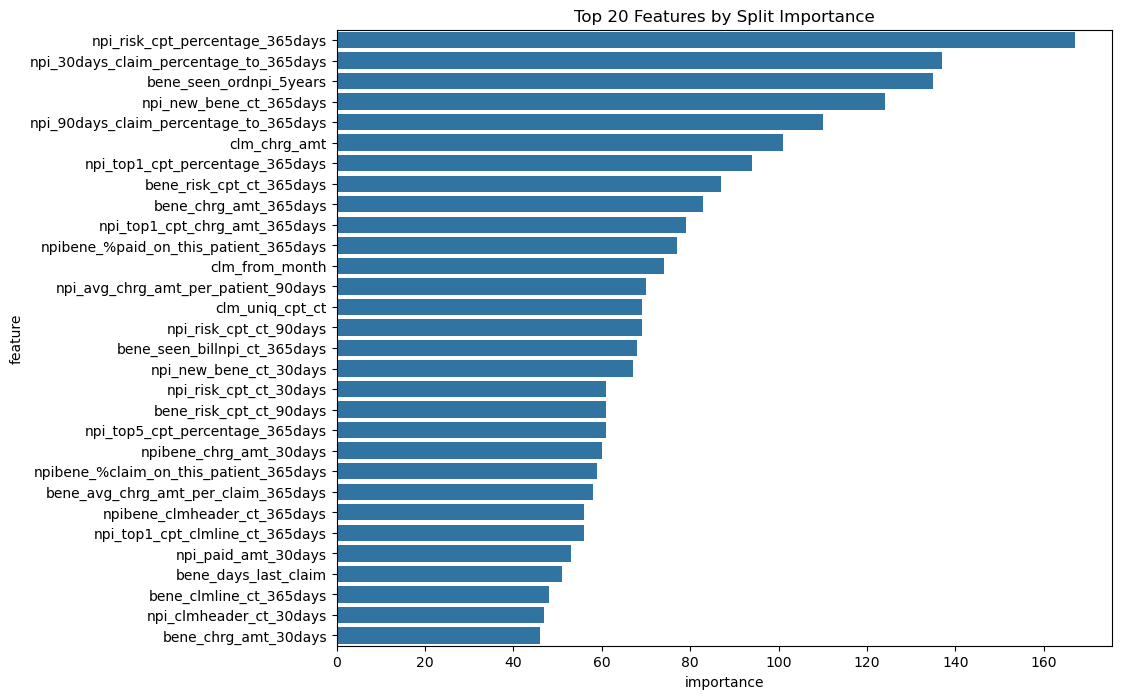

In [117]:
#Feature Importance by split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 获取特征重要性
feat_imp_split = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_imp_split.head(30))
plt.title('Top 20 Features by Split Importance')
plt.show()

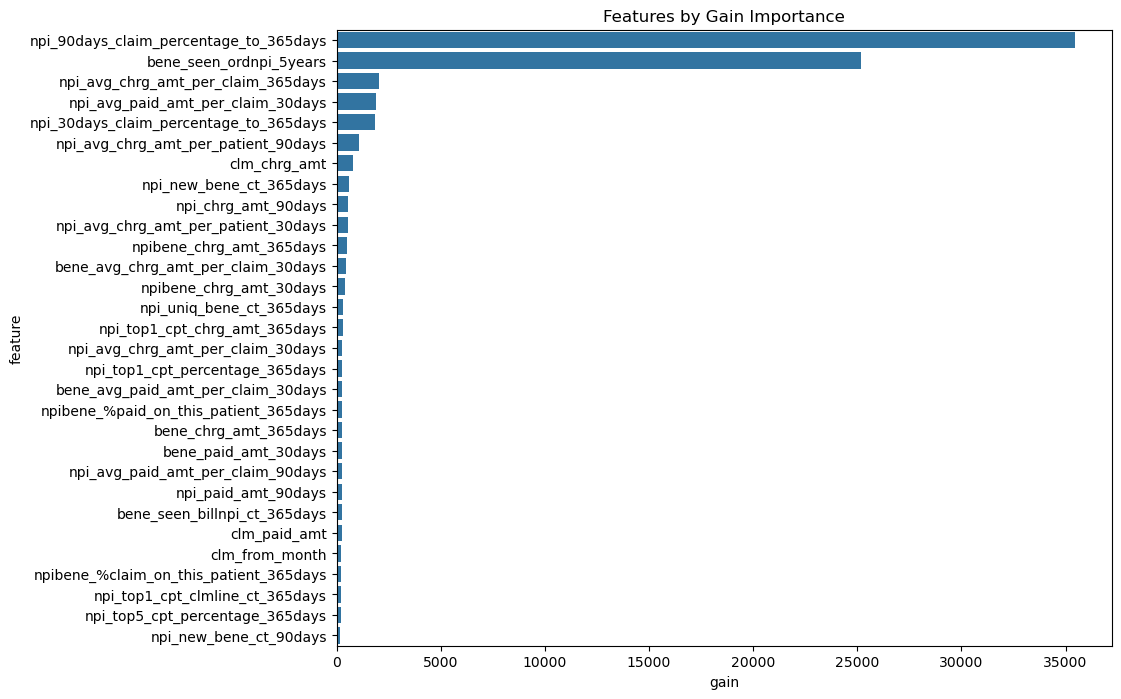

In [131]:
#Feature Importance by gain
feat_imp_gain = pd.DataFrame({
    'feature': X_train.columns,
    'gain': model.booster_.feature_importance(importance_type='gain')
}).sort_values('gain', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='gain', y='feature', data=feat_imp_gain.head(30))
plt.title('Features by Gain Importance')
plt.show()

In [ ]:
# Remove 0 Gain Features
columns = [column for column in df_tran.columns if column in ( feat_imp_gain.loc[feat_imp_gain['gain'] == 0, 'feature'].tolist())]
df_tran = df_tran.drop(columns=columns)

In [ ]:
# 找到高相关的特征对
sorted_columns = feat_imp_gain.sort_values(by='gain', ascending=False)['feature'].values
X_train = X_train[sorted_columns] 

corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"建议删除的高相关特征数量: {len(to_drop)}")
print(to_drop)

df_tran = df_tran.drop(columns=to_drop)

# **2. Split Train, Validation, Test Dataset**

In [17]:
#split independent and dependent variables
drop_cols = [
    'fraud_flag',
    'cur_clm_uniq_id',
    'clm_beneficiary_id',
    'clm_billnpi',
    'clm_ordenpi',
    'clm_from_dt',
    'clm_all_cpts'
    ''
]
X = df_tran.drop(columns=drop_cols)
Y = df_tran['fraud_flag']

In [99]:
#Remove Risk CPT for data leakage
X = X.drop(columns=[col for col in X.columns if 'risk' in col])

#Remove Amount and See Providers to Test NEW FEATURES captured by ML
#X = X.drop(columns=[col for col in X.columns if ('amt' in col]) & (['']))

In [102]:
X.columns.to_list()

['clm_chrg_amt',
 'clm_paid_amt',
 'clm_lines_ct',
 'clm_uniq_cpt_ct',
 'clm_thru_dt',
 'clm_from_month',
 'clm_from_day',
 'clm_duration_days',
 'original_clm_flag',
 'bene_clmline_ct_30days',
 'bene_clmline_ct_90days',
 'bene_clmline_ct_365days',
 'bene_clmheader_ct_30days',
 'bene_clmheader_ct_90days',
 'bene_clmheader_ct_365days',
 'bene_uniq_cpt_ct_30days',
 'bene_uniq_cpt_ct_90days',
 'bene_uniq_cpt_ct_365days',
 'bene_chrg_amt_30days',
 'bene_chrg_amt_90days',
 'bene_chrg_amt_365days',
 'bene_paid_amt_30days',
 'bene_paid_amt_90days',
 'bene_paid_amt_365days',
 'bene_uniq_ordernpi_30days',
 'bene_uniq_ordNpi_90days',
 'bene_uniq_ordnpi_365days',
 'bene_uniq_billnpi_30days',
 'bene_uniq_billnpi_90days',
 'bene_uniq_billnpi_365days',
 'bene_days_last_claim',
 'bene_seen_billnpi_ct_30days',
 'bene_seen_billnpi_ct_90days',
 'bene_seen_billnpi_ct_365days',
 'bene_seen_ordnpi_ct_30days',
 'bene_seen_orfnpi_ct_90days',
 'bene_seen_ordnpi_ct_365days',
 'bene_seen_ordnpi_5years',
 'bene_

In [103]:
#Check fraud claim distribution
df_tran['clm_thru_dt'] = pd.to_datetime(df_tran['clm_thru_dt'], errors='coerce')
df_tran.loc[df_tran['fraud_flag']==1].groupby(df_tran['clm_thru_dt'].dt.to_period('M')).size()

clm_thru_dt
2021-03      4
2021-04      6
2021-06      5
2021-07      7
2021-08      8
2021-09     11
2021-10     15
2021-11     30
2021-12     43
2022-01     46
2022-02     39
2022-03     73
2022-04     78
2022-05     81
2022-06     90
2022-07     84
2022-08     77
2022-09     68
2022-10     67
2022-11     85
2022-12    219
2023-01      9
2023-02     26
2023-03     38
2023-04     20
2023-05     37
2023-06     29
2023-07     23
2023-08     38
2023-09     50
2023-10     58
2023-11     12
2023-12     42
2024-01     63
2024-02     62
2024-03     50
2024-04     77
2024-05     31
2024-06    137
2024-07     66
2024-08     55
2024-09     31
2024-10     15
2024-11     33
2024-12     44
2025-01     29
2025-02     54
2025-03     41
2025-04     17
2025-05     19
2025-06     19
2025-07     25
2025-08     39
2025-09     57
2025-10     37
2025-11      3
2025-12      1
Freq: M, dtype: int64

In [20]:
# 计算 70% 和 85% 的分位日期
q1 = X['clm_thru_dt'].quantile(0.7)
q2 = X['clm_thru_dt'].quantile(0.85)
print(q1,q2)

# 拆分索引
train_idx = X['clm_thru_dt'] <= q1
valid_idx = (X['clm_thru_dt']>'2025-01-01') & (X['clm_thru_dt']<='2025-12-31') 
#(X['clm_thru_dt'] > q1) & (X['clm_thru_dt'] <= q2)
test_idx  = X['clm_thru_dt'] > q2

# 拆分 X 和 Y，同时删除日期列（如果不做特征的话）
X_train = X[train_idx].drop(columns=['clm_thru_dt'])
Y_train = Y[train_idx]

X_valid = X[valid_idx].drop(columns=['clm_thru_dt'])
Y_valid = Y[valid_idx]

X_test  = X[test_idx].drop(columns=['clm_thru_dt'])
Y_test  = Y[test_idx]

# 打印比例
print('Train %:', X_train.shape[0]/X.shape[0])
print('Validation %:', X_valid.shape[0]/X.shape[0])
print('Test %:', X_test.shape[0]/X.shape[0])

print('Positive Train %:', Y_train.sum() / Y.sum())
print('Positive Validation %:', Y_valid.sum() / Y.sum())
print('Positive Test %:', Y_test.sum() / Y.sum())

2024-05-28 00:00:00 2025-02-26 00:00:00
Train %: 0.7006316308795307
Validation %: 0.1761420728174675
Test %: 0.1494403356628164
Positive Train %: 0.7126436781609196
Positive Validation %: 0.13515655965120887
Positive Test %: 0.10265556876734047


### **Balance Dataset**

In [ ]:
# 使用 SMOTE-Tomek 综合采样（过采样 + 欠采样）
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# sampling_strategy=0.3 表示让少数类样本数量增加到多数类数量的 30%
smote_sampler = SMOTE(sampling_strategy=0.3, random_state=42)

# 定义 SMOTE-Tomek 采样器
# 它会先执行 SMOTE，然后通过 Tomek Links 剔除边界噪声样本
smt = SMOTETomek(smote=smote_sampler, random_state=42)

# 对训练集进行重新采样\
X_res, Y_res = smt.fit_resample(X_train, Y_train)

In [ ]:
#Random Oversampling
# 使用 Random Oversampling（随机过采样）
from imblearn.over_sampling import RandomOverSampler

# sampling_strategy=0.3 表示让少数类样本数量增加到多数类数量的 30%
ros = RandomOverSampler(sampling_strategy=0.3, random_state=42)

# 只对训练集做过采样
X_res, Y_res = ros.fit_resample(X_train, Y_train)

In [22]:
#Scale Weight for Model
scale_pos_weight = (
    df_tran.loc[df_tran['fraud_flag'] == 0].shape[0] /
    df_tran.loc[df_tran['fraud_flag'] == 1].shape[0]
)

print(scale_pos_weight)

X_res, Y_res = X_train, Y_train

699.5501387237416


In [23]:
Y_res.value_counts()

fraud_flag
0    1236560
1       1798
Name: count, dtype: int64

# **3. Modeling**

### **Light GBM**

In [79]:
#Import
import lightgbm as lgb

model_lgbm = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.03,
    num_leaves=16,
    min_data_in_leaf=50,   # 可以适当调大
    feature_fraction=0.9,
    bagging_fraction=1,
    bagging_freq=5,
    n_estimators=5000,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Fit without verbose
model_lgbm.fit(
    X_res, Y_res,
    eval_set=[(X_valid, Y_valid)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=1, subsample=1.0 will be ignored. Current value: bagging_fraction=1
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=1, subsample=1.0 will be ignored. Current value: bagging_fraction=1
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Number of positive: 1798, number of negative: 12

,boosting_type,'gbdt'
,num_leaves,16
,max_depth,-1
,learning_rate,0.03
,n_estimators,5000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [80]:
#Evaluate Validation Dataset
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve, average_precision_score, precision_recall_curve, f1_score

# 预测
Y_pred_prob = model_lgbm.predict_proba(X_valid)[:,1]  # 保留概率
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(Y_valid, (Y_pred_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f'threshold {best_threshold}')
Y_pred_class = (Y_pred_prob >= best_threshold).astype(int)  # 转换为类别

# AUC
auc = roc_auc_score(Y_valid, Y_pred_prob)
print(f"AUC: {auc:.4f}")

# PR-AUC
pr_auc = average_precision_score(Y_valid, Y_pred_prob)
print(f"PR-AUC: {pr_auc:.4f}")

# 混淆矩阵
cm = confusion_matrix(Y_valid, Y_pred_class)
tn, fp, fn, tp = cm.ravel()
# create a labeled DataFrame
cm_df = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=['Actual Non-Fraud (0)', 'Actual Fraud (1)'],
    columns=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)']
)
print(cm_df)

# 分类报告
report = classification_report(Y_valid, Y_pred_class)
print("\nClassification Report:\n", report)

#Top-k 分析
df_eval = X_valid.copy()
df_eval['fraud_flag'] = Y_valid.values
df_eval['score'] = Y_pred_prob


total_fraud = df_eval['fraud_flag'].sum()
for pct in [0.01, 0.02, 0.05,0.1,0.2,0.5]:
    top_pct = df_eval.sort_values('score', ascending=False) \
                     .head(int(pct * len(df_eval)))

    # Top-K fraud rate (precision)
    fraud_rate = top_pct['fraud_flag'].mean()

    # Top-K recall
    fraud_captured = top_pct['fraud_flag'].sum()
    recall_at_k = fraud_captured / total_fraud

    print(
        f"Top {int(pct*100)}% | "
        f"Fraud Rate: {fraud_rate:.4f} | "
        f"Recall: {recall_at_k:.4f}"
    )


# KS 统计量
fpr, tpr, thresholds = roc_curve(Y_valid, Y_pred_prob)
ks = max(tpr - fpr)
print(f"KS statistic: {ks:.4f}")

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=1, subsample=1.0 will be ignored. Current value: bagging_fraction=1
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
threshold 0.32
AUC: 0.6096
PR-AUC: 0.0327
                      Predicted Non-Fraud (0)  Predicted Fraud (1)
Actual Non-Fraud (0)                   304660                 6328
Actual Fraud (1)                          155                  186

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    310988
           1       0.03      0.55      0.05       341

    accuracy                           0.98    311329
   macro avg       0.51      0.76      0.52    

In [108]:
#Export validation data
df_valid = X_valid.copy()
df_valid['cur_clm_uniq_id'] = df_tran.loc[X_valid.index, 'cur_clm_uniq_id']
df_valid['fraud_flag'] = Y_valid
df_valid['pred_prob'] = pd.Series(Y_pred_prob, index=df_valid.index)
df_valid.to_csv(r'U:\Zeming\AAA-Project\DME Fraud Claims Detection\Validation\Valid_pred_LGBM.csv')

### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize features (important for LR)
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_valid_scaled = scaler.transform(X_valid)

# Train Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',  # handle imbalance
    solver='liblinear',       # good for small/medium dataset
    max_iter=1000
)
lr_model.fit(X_res_scaled, Y_res)

# Predict probabilities
Y_pred_prob = lr_model.predict_proba(X_valid_scaled)[:,1]

# Threshold
best_threshold = 0.06
Y_pred_class = (Y_pred_prob >= best_threshold).astype(int)

# AUC & PR-AUC
from sklearn.metrics import roc_auc_score, average_precision_score
auc = roc_auc_score(Y_valid, Y_pred_prob)
pr_auc = average_precision_score(Y_valid, Y_pred_prob)
print(f"Logistic Regression AUC: {auc:.4f}")
print(f"Logistic Regression PR-AUC: {pr_auc:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(Y_valid, Y_pred_class)
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=['Actual Non-Fraud (0)', 'Actual Fraud (1)'],
    columns=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)']
)
print(cm_df)

# Classification report
report = classification_report(Y_valid, Y_pred_class)
print("\nClassification Report:\n", report)

# Top-K analysis
df_eval = X_valid.copy()
df_eval['fraud_flag'] = Y_valid.values
df_eval['score'] = Y_pred_prob

total_fraud = df_eval['fraud_flag'].sum()
for pct in [0.01, 0.02, 0.05]:
    top_pct = df_eval.sort_values('score', ascending=False).head(int(pct*len(df_eval)))
    fraud_rate = top_pct['fraud_flag'].mean()
    recall_at_k = top_pct['fraud_flag'].sum() / total_fraud
    print(f"Top {int(pct*100)}% | Fraud Rate: {fraud_rate:.4f} | Recall: {recall_at_k:.4f}")

# KS statistic
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(Y_valid, Y_pred_prob)
ks = max(tpr - fpr)
print(f"KS statistic: {ks:.4f}")


### **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=None, 
    min_samples_leaf=100,  # similar to LightGBM min_data_in_leaf
    class_weight='balanced',  # handle imbalance
    random_state=42
)
dt_model.fit(X_res, Y_res)

# Predict probabilities
Y_pred_prob = dt_model.predict_proba(X_valid)[:,1]

# Threshold
best_threshold = 0.06
Y_pred_class = (Y_pred_prob >= best_threshold).astype(int)

# AUC & PR-AUC
auc = roc_auc_score(Y_valid, Y_pred_prob)
pr_auc = average_precision_score(Y_valid, Y_pred_prob)
print(f"Decision Tree AUC: {auc:.4f}")
print(f"Decision Tree PR-AUC: {pr_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(Y_valid, Y_pred_class)
tn, fp, fn, tp = cm.ravel()
cm_df = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=['Actual Non-Fraud (0)', 'Actual Fraud (1)'],
    columns=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)']
)
print(cm_df)

# Classification report
report = classification_report(Y_valid, Y_pred_class)
print("\nClassification Report:\n", report)

# Top-K analysis
df_eval = X_valid.copy()
df_eval['fraud_flag'] = Y_valid.values
df_eval['score'] = Y_pred_prob

total_fraud = df_eval['fraud_flag'].sum()
for pct in [0.01, 0.02, 0.05]:
    top_pct = df_eval.sort_values('score', ascending=False).head(int(pct*len(df_eval)))
    fraud_rate = top_pct['fraud_flag'].mean()
    recall_at_k = top_pct['fraud_flag'].sum() / total_fraud
    print(f"Top {int(pct*100)}% | Fraud Rate: {fraud_rate:.4f} | Recall: {recall_at_k:.4f}")

# KS statistic
fpr, tpr, thresholds = roc_curve(Y_valid, Y_pred_prob)
ks = max(tpr - fpr)
print(f"KS statistic: {ks:.4f}")


### **Positive Unlabel**

In [24]:
# Positive Index
idx_P = Y_res[Y_res == 1].index

# Unlabeled Index
idx_U = Y_res[Y_res == 0].index

X_P = X_res.loc[idx_P]
X_U = X_res.loc[idx_U]

In [83]:
import lightgbm as lgb

# Step 1: 从未标记中随机选一些当作初始负样本
np.random.seed(42)
neg_sample_size = len(X_P) * 10  #3 times Postive as Negative
init_neg_idx = np.random.choice(len(X_U), size=neg_sample_size, replace=False)
X_N_init = X_U.iloc[init_neg_idx]

# 样本权重
weight_P = 1.0
weight_N = len(X_P) / len(X_N_init)  # 负样本较多时调小
weights = np.array([weight_P]*len(X_P) + [weight_N]*len(X_N_init))

# Step 2: 合并正样本 + 初始负样本
X_train_pu = pd.concat([X_P, X_N_init])
Y_train_pu = np.concatenate([np.ones(len(X_P)), np.zeros(len(X_N_init))])

# Step 3: LightGBM 训练
model = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.03,
    num_leaves=16,
    n_estimators=5000,
    random_state=42
)

model.fit(
    X_train_pu, Y_train_pu,
    eval_set=[(X_valid, Y_valid)],
    sample_weight=weights,
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

[LightGBM] [Info] Number of positive: 1798, number of negative: 17980
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18664
[LightGBM] [Info] Number of data points in the train set: 19778, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[152]	valid_0's average_precision: 0.079865	valid_0's binary_logloss: 0.0814616


,boosting_type,'gbdt'
,num_leaves,16
,max_depth,-1
,learning_rate,0.03
,n_estimators,5000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [89]:
# --- 1. 预测剩余样本的概率 ---
# 注意：只预测那些既不在正样本集，也不在初始负样本集中的数据
X_U_remaining = X_U.drop(X_N_init.index)
probs_U_remaining = model.predict_proba(X_U_remaining)[:,1]

# --- 2. 识别高概率样本 (打捞) ---
threshold_newP = 0.97
X_new_P = X_U_remaining[probs_U_remaining >= threshold_newP]

# --- 3. 核心改进：清理初始负样本 (Reliable Negatives) ---
probs_N_init = model.predict_proba(X_N_init)[:,1]

# 找出 X_N_init 中概率特别高的样本（这些是随机抽样带来的“间谍”或噪声）
noise_in_neg_mask = probs_N_init >= threshold_newP
X_N_init_clean = X_N_init[~noise_in_neg_mask]

print(f"从初始负样本中剔除了 {sum(noise_in_neg_mask)} 个高风险噪点。")
print(f"打捞回来的新正样本 (X_new_P) 数量: {len(X_new_P)}")

# --- 4. 构建最终训练集 ---
X_final = pd.concat([X_P, X_new_P, X_N_init_clean])

# 标签对齐
Y_final = np.concatenate([
    np.ones(len(X_P)),           # 原始正样本
    np.ones(len(X_new_P)),       # 打捞正样本
    np.zeros(len(X_N_init_clean)) # 清理后的可靠负样本
])

# --- 5. 权重精细化管理 ---
# 我们给打捞回来的样本较低权重，因为它们是“预测”出来的，不是“证实”的
weights_final = np.concatenate([
    np.ones(len(X_P)) * 1, 
    np.ones(len(X_new_P)) * 0.5, 
    np.ones(len(X_N_init_clean)) * 0.1
])

# --- 6. 最终模型训练 ---
model_final = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.03,
    num_leaves=16,
    n_estimators=5000,
    random_state=42,
    importance_type='gain' # 建议改为 gain，对业务分析更有用
)

model_final.fit(
    X_final, Y_final,
    eval_set=[(X_valid, Y_valid)],
    eval_metric='average_precision',
    sample_weight=weights_final,
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

从初始负样本中剔除了 97 个高风险噪点。
打捞回来的新正样本 (X_new_P) 数量: 7440
[LightGBM] [Info] Number of positive: 9238, number of negative: 17883
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18793
[LightGBM] [Info] Number of data points in the train set: 27121, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.755239 -> initscore=1.126750
[LightGBM] [Info] Start training from score 1.126750
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[205]	valid_0's average_precision: 0.0970973	valid_0's binary_logloss: 0.0853005


,boosting_type,'gbdt'
,num_leaves,16
,max_depth,-1
,learning_rate,0.03
,n_estimators,5000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [90]:
#Evaluate Validation Dataset
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve, average_precision_score, precision_recall_curve, f1_score

# 预测
Y_pred_prob = model_final.predict_proba(X_valid)[:,1]  # 保留概率
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(Y_valid, (Y_pred_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f'threshold {best_threshold}')
Y_pred_class = (Y_pred_prob >= best_threshold).astype(int)  # 转换为类别

# AUC
auc = roc_auc_score(Y_valid, Y_pred_prob)
print(f"AUC: {auc:.4f}")

# PR-AUC
pr_auc = average_precision_score(Y_valid, Y_pred_prob)
print(f"PR-AUC: {pr_auc:.4f}")

# 混淆矩阵
cm = confusion_matrix(Y_valid, Y_pred_class)
tn, fp, fn, tp = cm.ravel()
# create a labeled DataFrame
cm_df = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=['Actual Non-Fraud (0)', 'Actual Fraud (1)'],
    columns=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)']
)

print(cm_df)

# 分类报告
report = classification_report(Y_valid, Y_pred_class)
print("\nClassification Report:\n", report)

#Top-k 分析
df_eval = X_valid.copy()
df_eval['fraud_flag'] = Y_valid.values
df_eval['score'] = Y_pred_prob


total_fraud = df_eval['fraud_flag'].sum()
for pct in [0.005,0.01, 0.02, 0.05,0.1,0.2,0.5]:
    top_pct = df_eval.sort_values('score', ascending=False) \
                     .head(int(pct * len(df_eval)))

    # Top-K fraud rate (precision)
    fraud_rate = top_pct['fraud_flag'].mean()

    # Top-K recall
    fraud_captured = top_pct['fraud_flag'].sum()
    recall_at_k = fraud_captured / total_fraud

    print(
        f"Top {float(pct*100)}% | "
        f"Fraud Rate: {fraud_rate:.4f} | "
        f"Recall: {recall_at_k:.4f}"
    )


# KS 统计量
fpr, tpr, thresholds = roc_curve(Y_valid, Y_pred_prob)
ks = max(tpr - fpr)
print(f"KS statistic: {ks:.4f}")

threshold 0.99
AUC: 0.9810
PR-AUC: 0.0971
                      Predicted Non-Fraud (0)  Predicted Fraud (1)
Actual Non-Fraud (0)                   309445                 1543
Actual Fraud (1)                          185                  156

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    310988
           1       0.09      0.46      0.15       341

    accuracy                           0.99    311329
   macro avg       0.55      0.73      0.58    311329
weighted avg       1.00      0.99      1.00    311329

Top 0.5% | Fraud Rate: 0.0958 | Recall: 0.4370
Top 1.0% | Fraud Rate: 0.0678 | Recall: 0.6188
Top 2.0% | Fraud Rate: 0.0443 | Recall: 0.8094
Top 5.0% | Fraud Rate: 0.0209 | Recall: 0.9560
Top 10.0% | Fraud Rate: 0.0107 | Recall: 0.9795
Top 20.0% | Fraud Rate: 0.0054 | Recall: 0.9853
Top 50.0% | Fraud Rate: 0.0022 | Recall: 0.9883
KS statistic: 0.9199


                                    feature  gain
36                  bene_seen_ordnpi_5years   158
87   npi_30days_claim_percentage_to_365days   136
88   npi_90days_claim_percentage_to_365days   114
61                  npi_new_bene_ct_365days    84
104  npibene_%claim_on_this_patient_365days    71
80          npi_top1_cpt_percentage_365days    70
0                              clm_chrg_amt    62
50                  npi_uniq_bene_ct_30days    56
78        npi_avg_paid_amt_per_claim_90days    53
69      npi_avg_chrg_amt_per_patient_90days    52
19                    bene_chrg_amt_365days    51
4                            clm_from_month    50
1                              clm_paid_amt    47
81          npi_top5_cpt_percentage_365days    44
52                 npi_uniq_bene_ct_365days    43
74        npi_avg_chrg_amt_per_claim_30days    42
66            npi_top1_cpt_paid_amt_365days    41
105   npibene_%paid_on_this_patient_365days    41
64            npi_top1_cpt_chrg_amt_365days    40


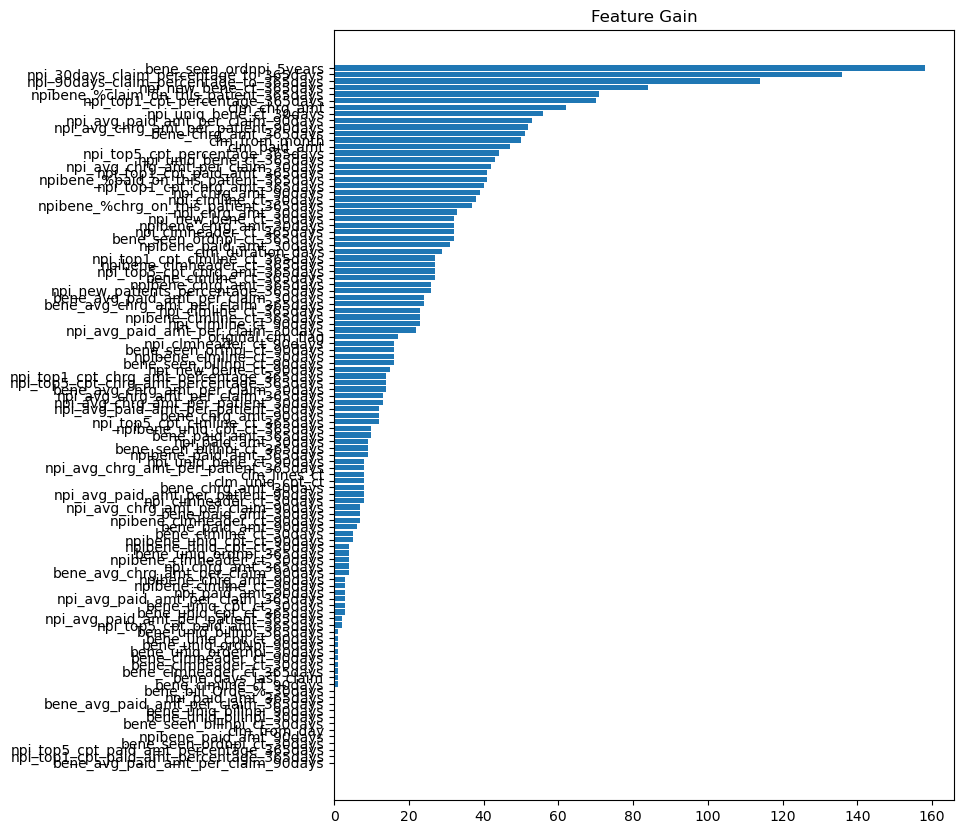

In [106]:
gain = model.feature_importances_  # 默认按 split 次数，也可以用 importance_type='gain'

# 创建 DataFrame
feat_imp = pd.DataFrame({
    'feature': X_valid.columns,
    'gain': gain
}).sort_values('gain', ascending=False)

print(feat_imp.head(20))

# 可视化
plt.figure(figsize=(8,10))
plt.barh(feat_imp['feature'], feat_imp['gain'])
plt.gca().invert_yaxis()
plt.title("Feature Gain")
plt.show()

                                    feature       gain
88   npi_90days_claim_percentage_to_365days 102124.172
36                  bene_seen_ordnpi_5years   8146.913
0                              clm_chrg_amt   3056.389
98                  npibene_chrg_amt_30days   2630.590
68      npi_avg_chrg_amt_per_patient_30days   2221.236
87   npi_30days_claim_percentage_to_365days   1657.680
61                  npi_new_bene_ct_365days   1424.283
75        npi_avg_chrg_amt_per_claim_90days   1211.743
101                 npibene_paid_amt_30days   1047.299
74        npi_avg_chrg_amt_per_claim_30days    528.051
57                      npi_paid_amt_90days    452.596
50                  npi_uniq_bene_ct_30days    402.214
69      npi_avg_chrg_amt_per_patient_90days    392.711
104  npibene_%claim_on_this_patient_365days    375.876
48                  npi_clmheader_ct_90days    359.856
1                              clm_paid_amt    350.473
100                npibene_chrg_amt_365days    330.681
49        

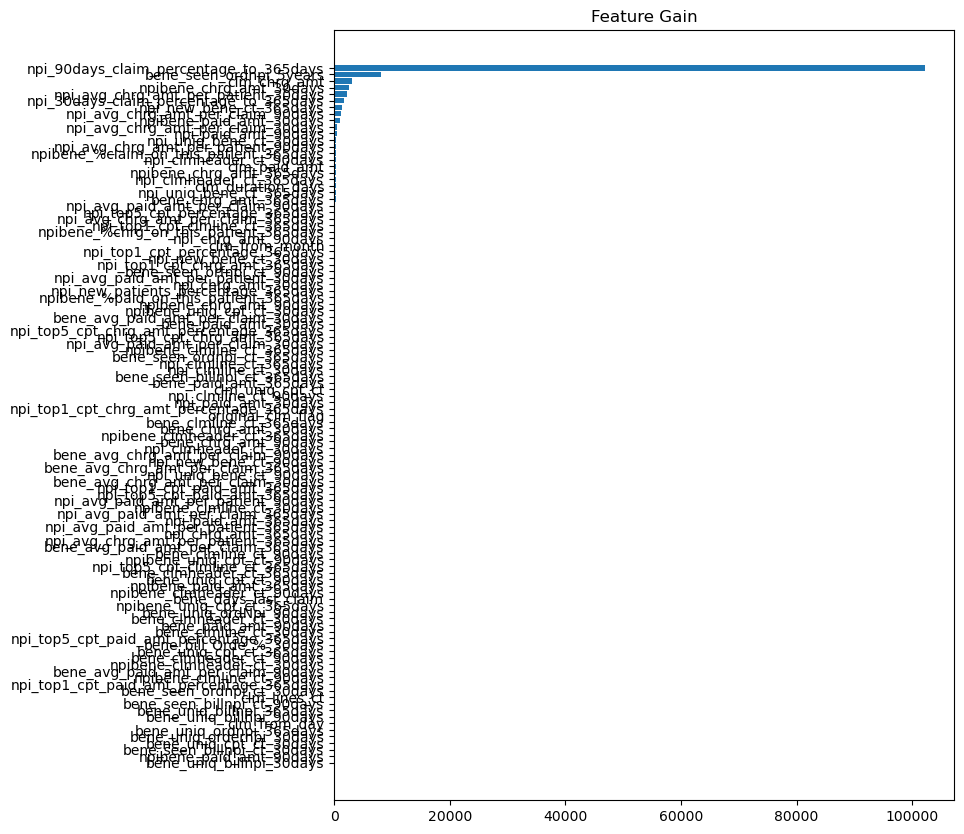

In [98]:
import matplotlib.pyplot as plt
import lightgbm as lgb

gain = model_final.feature_importances_  # 默认按 split 次数，也可以用 importance_type='gain'

# 创建 DataFrame
feat_imp = pd.DataFrame({
    'feature': X_valid.columns,
    'gain': gain
}).sort_values('gain', ascending=False)

print(feat_imp.head(20))

# 可视化
plt.figure(figsize=(8,10))
plt.barh(feat_imp['feature'], feat_imp['gain'])
plt.gca().invert_yaxis()
plt.title("Feature Gain")
plt.show()

In [97]:
#Export validation data
df_valid = X_valid.copy()
df_valid['cur_clm_uniq_id'] = df_tran.loc[X_valid.index, 'cur_clm_uniq_id']
df_valid['fraud_flag'] = Y_valid
df_valid['pred_prob'] = pd.Series(Y_pred_prob, index=df_valid.index)
df_valid.to_csv(r'U:\Zeming\AAA-Project\DME Fraud Claims Detection\Validation\Valid_pred_PULGBM_RemoveRisk_2025test_forMichael_New.csv')

In [108]:
df_valid[df_valid['pred_prob'] > df_valid['pred_prob'].quantile(0.99)]['']

,clm_chrg_amt,clm_paid_amt,clm_lines_ct,clm_uniq_cpt_ct,clm_from_month,clm_from_day,clm_duration_days,original_clm_flag,bene_clmline_ct_30days,bene_clmline_ct_90days,bene_clmline_ct_365days,bene_clmheader_ct_30days,bene_clmheader_ct_90days,bene_clmheader_ct_365days,bene_uniq_cpt_ct_30days,bene_uniq_cpt_ct_90days,bene_uniq_cpt_ct_365days,bene_chrg_amt_30days,bene_chrg_amt_90days,bene_chrg_amt_365days,bene_paid_amt_30days,bene_paid_amt_90days,bene_paid_amt_365days,bene_uniq_ordernpi_30days,bene_uniq_ordNpi_90days,bene_uniq_ordnpi_365days,bene_uniq_billnpi_30days,bene_uniq_billnpi_90days,bene_uniq_billnpi_365days,bene_days_last_claim,bene_seen_billnpi_ct_30days,bene_seen_billnpi_ct_90days,bene_seen_billnpi_ct_365days,bene_seen_ordnpi_ct_30days,bene_seen_orfnpi_ct_90days,bene_seen_ordnpi_ct_365days,bene_seen_ordnpi_5years,bene_avg_chrg_amt_per_claim_30days,bene_avg_chrg_amt_per_claim_90days,bene_avg_chrg_amt_per_claim_365days,bene_avg_paid_amt_per_claim_30days,bene_avg_paid_amt_per_claim_90days,bene_avg_paid_amt_per_claim_365days,bene_bill_Orde_%_30days,npi_clmline_ct_30days,npi_clmline_ct_90days,npi_clmline_ct_365days,npi_clmheader_ct_30days,npi_clmheader_ct_90days,npi_clmheader_ct_365days,npi_uniq_bene_ct_30days,npi_uniq_bene_ct_90days,npi_uniq_bene_ct_365days,npi_chrg_amt_30days,npi_chrg_amt_90days,npi_chrg_amt_365days,npi_paid_amt_30days,npi_paid_amt_90days,npi_paid_amt_365days,npi_new_bene_ct_30days,npi_new_bene_ct_90days,npi_new_bene_ct_365days,npi_top1_cpt_clmline_ct_365days,npi_top5_cpt_clmline_ct_365days,npi_top1_cpt_chrg_amt_365days,npi_top5_cpt_chrg_amt_365days,npi_top1_cpt_paid_amt_365days,npi_top5_cpt_paid_amt_365days,npi_avg_chrg_amt_per_patient_30days,npi_avg_chrg_amt_per_patient_90days,npi_avg_chrg_amt_per_patient_365days,npi_avg_paid_amt_per_patient_30days,npi_avg_paid_amt_per_patient_90days,npi_avg_paid_amt_per_patient_365days,npi_avg_chrg_amt_per_claim_30days,npi_avg_chrg_amt_per_claim_90days,npi_avg_chrg_amt_per_claim_365days,npi_avg_paid_amt_per_claim_30days,npi_avg_paid_amt_per_claim_90days,npi_avg_paid_amt_per_claim_365days,npi_top1_cpt_percentage_365days,npi_top5_cpt_percentage_365days,npi_top1_cpt_chrg_amt_percentage_365days,npi_top5_cpt_chrg_amt_percentage_365days,npi_top1_cpt_paid_amt_percentage_365days,npi_top5_cpt_paid_amt_percentage_365days,npi_new_patients_percentage_365days,npi_30days_claim_percentage_to_365days,npi_90days_claim_percentage_to_365days,npibene_clmline_ct_30days,npibene_clmline_ct_90days,npibene_clmline_ct_365days,npibene_clmheader_ct_30days,npibene_clmheader_ct_90days,npibene_clmheader_ct_365days,npibene_uniq_cpt_ct_30days,npibene_uniq_cpt_ct_90days,npibene_uniq_cpt_ct_365days,npibene_chrg_amt_30days,npibene_chrg_amt_90days,npibene_chrg_amt_365days,npibene_paid_amt_30days,npibene_paid_amt_90days,npibene_paid_amt_365days,npibene_%claim_on_this_patient_365days,npibene_%paid_on_this_patient_365days,npibene_%chrg_on_this_patient_365days,cur_clm_uniq_id,fraud_flag,pred_prob
1441541,1425.870,1117.880,3,3,1,4,1,0,7,7,35,2,2,10,7,7,10,1721.900,1721.900,3010.800,1148.480,1148.480,1994.630,2,2,2,2,2,2,2.000,0,0,0,0,0,0,1,860.950,860.950,301.080,574.240,574.240,199.463,1.000,42,52,61,14,21,27,13,19,23,20146.320,26129.250,30328.530,15391.860,20082.490,23374.730,3,9,41,11,43,5274.870,9807.490,4135.550,7594.920,1549.717,1375.224,1318.632,1183.989,1056.973,1016.293,1439.023,1244.250,1123.279,1099.419,956.309,865.731,0.180,0.705,0.174,0.323,0.177,0.325,1.783,0.519,0.778,3,3,3,1,1,1,3,3,3,1425.870,1425.870,1425.870,1117.880,1117.880,1117.880,0.043,0.048,0.047,1004595763943,0,0.994
1441625,2332.400,1627.120,3,2,1,1,1,0,3,3,3,1,1,1,2,2,2,2332.400,2332.400,2332.400,1627.120,1627.120,1627.120,1,1,1,1,1,1,999.000,0,0,0,0,0,0,1,2332.400,2332.400,2332.400,1627.120,1627.120,1627.120,1.000,40,48,57,14,19,25,13,17,21,19020.650,23543.100,27742.380,14509.340,18054.950,21347.190,0,0,0,2,3,1172.120,2332.400,909.660,1627.120,1463.127,1384.888,1321.066,1116.103,1062.056,1016.533,1358.618,1239.111,1109.695,1036.381,95